In [91]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.utilities import ricker_wavelet, green2d

In [93]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX
    "font.family": "serif",      # Use serif fonts
    "font.size": 18,             # Set font size
    "axes.labelsize": 18,        # Label font size
    "legend.fontsize": 18,       # Legend font size
    "xtick.labelsize": 18,       # X-axis tick size
    "ytick.labelsize": 18,       # Y-axis tick size
    "figure.figsize": (8,6),     # Set figure size
    "lines.linewidth": 1.5,        # Line thickness
    "grid.alpha": 0.5,           # Grid transparency
    "savefig.dpi": 300           # High-resolution images
})

In [94]:
#layers = [
#        (300.0, 1500.0, 2000.0), # top layer
#        (400.0, 4000.0, 2000.0),#350
#        (500.0, 5500.0, 2000.0)#390
#    ]

layers = [
        (500.0, 1500.0, 2000.0), # top layer
        (2000.0, 4500.0, 2000.0),
        (3000.0, 3000.0, 2000.0),
        (2500.0, 3800.0, 2000.0)
    ]

In [95]:
'''layers = [
        (100.0, 1505.0, 2000.0), # top layer
        (200.0, 1603.0, 2000.0),
        (250.0, 1749.0, 2000.0),
        (350.0, 2019.0, 2000.0),
        (450.0, 2179.0, 2000.0),
        (550.0, 1900.0, 2000.0),
        (650.0, 2265.0, 2000.0),
        (700.0, 3281.0, 2000.0),
    ]'''

'layers = [\n        (100.0, 1505.0, 2000.0), # top layer\n        (200.0, 1603.0, 2000.0),\n        (250.0, 1749.0, 2000.0),\n        (350.0, 2019.0, 2000.0),\n        (450.0, 2179.0, 2000.0),\n        (550.0, 1900.0, 2000.0),\n        (650.0, 2265.0, 2000.0),\n        (700.0, 3281.0, 2000.0),\n    ]'

dt = 0.011111111111111112
nfft = 256
nt = 190


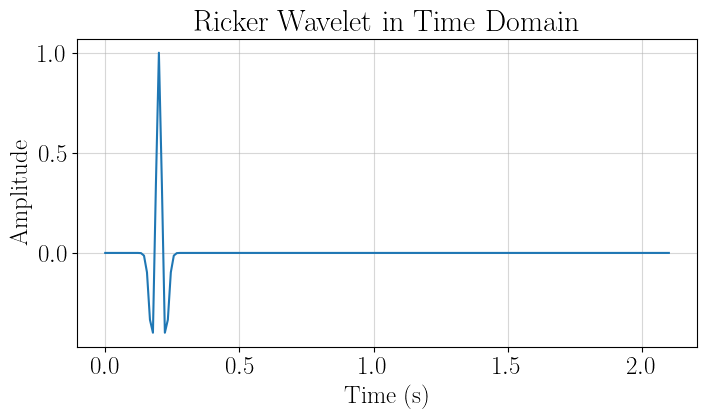

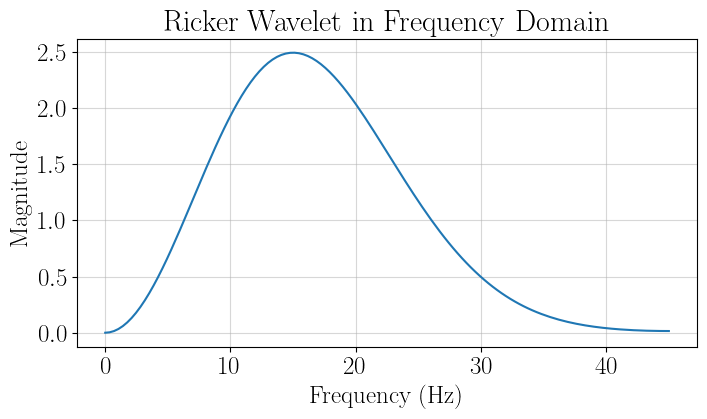

In [96]:
total_time = 2.1    # seconds
f0 = 15.0           # Ricker central frequency (Hz)
f_max = 3.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
#nt = 256
f0 = 15.0
f_max = 3. * f0  
print("dt =", dt)
#dt = total_time / (nt-1)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
print("nfft =", nfft)
nt = int(total_time / dt) + 1
print("nt =", nt)
time = np.arange(nt) * dt

#epsilon = 0.5
s_t, delay = ricker_wavelet(time, f0)
#s_t = s_t * np.exp(-epsilon * time)
S_w = np.conj(np.fft.rfft(s_t, n=nfft))

plt.figure(figsize=(8,4))
plt.plot(time, s_t, label='Ricker wavelet (f0={} Hz)'.format(f0))
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Ricker Wavelet in Time Domain')
plt.grid()
plt.show()

plt.figure(figsize=(8,4))
freqs = np.fft.rfftfreq(nfft, dt)
plt.plot(freqs, np.abs(S_w), label='Ricker wavelet Spectrum (f0={} Hz)'.format(f0))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Ricker Wavelet in Frequency Domain')
plt.grid()
plt.show()

In [97]:
Signal = np.load("R_map.npz")['R_map']
Signal = Signal[0, 20, :]  # Take first source
print("shape", Signal.shape)
print("shape", S_w.shape)
U_w = Signal * S_w
Nw = len(U_w)
taper_freq = np.hanning(2*Nw)[Nw:] 
U_w_hann = U_w * taper_freq
plt.figure(figsize=(8,4))
freqs = np.fft.rfftfreq(nfft, dt)
plt.plot(freqs, np.abs(U_w),'b' ,label='signal spectrum')
plt.plot(freqs, np.abs(U_w_hann), 'r', label='signal spectrum (Hanning tapered)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# Optionally enforce Hermitian symmetry if solver produces small asymmetries
# 6) Physics inverse FFT → clean time signal
u_t = np.conj(np.fft.irfft(np.conj(U_w), n=nfft))
u_t_hann = np.conj(np.fft.irfft(np.conj(U_w_hann), n=nfft))
plt.plot(time, u_t[:nt], 'b')
plt.plot(time, u_t_hann[:nt], 'r')
plt.xlabel('Time (s)')

shape (513,)
shape (129,)


ValueError: operands could not be broadcast together with shapes (513,) (129,) 

In [98]:
total_time = 2.    # seconds
f0 = 10.0           # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
print("dt =", dt)
#dt = total_time / (nt-1)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 2 # zero-padding to ensure late wrap-around
print("nfft =", nfft)
nt = int(total_time / dt) + 1
print("nt =", nt)
#time = np.arange(nt) * dt

param = Parameters(total_time=total_time, nt=nt, freq=f0, nfft=nfft) # 256

# x and z positions of sources
sources = [(3000.0, 76.0), (500.0, 76.0)]#], (250.0, 76.0), (350.0, 76.0), (480.0, 76.0), (620.0, 76.0)]
# x and z positions of receivers
Nr = 128 # 
x_receivers = np.linspace(0.0, 3000.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

dt = 0.00625
nfft = 1024
nt = 321
[(np.float64(0.0), 76.0), (np.float64(23.62204724409449), 76.0), (np.float64(47.24409448818898), 76.0), (np.float64(70.86614173228347), 76.0), (np.float64(94.48818897637796), 76.0), (np.float64(118.11023622047244), 76.0), (np.float64(141.73228346456693), 76.0), (np.float64(165.35433070866142), 76.0), (np.float64(188.9763779527559), 76.0), (np.float64(212.5984251968504), 76.0), (np.float64(236.2204724409449), 76.0), (np.float64(259.8425196850394), 76.0), (np.float64(283.46456692913387), 76.0), (np.float64(307.0866141732283), 76.0), (np.float64(330.70866141732284), 76.0), (np.float64(354.33070866141736), 76.0), (np.float64(377.9527559055118), 76.0), (np.float64(401.5748031496063), 76.0), (np.float64(425.1968503937008), 76.0), (np.float64(448.8188976377953), 76.0), (np.float64(472.4409448818898), 76.0), (np.float64(496.06299212598424), 76.0), (np.float64(519.6850393700788), 76.0), (np.float64(543.3070866141733), 76.0), (np.float64(566.9291338582677), 76.0

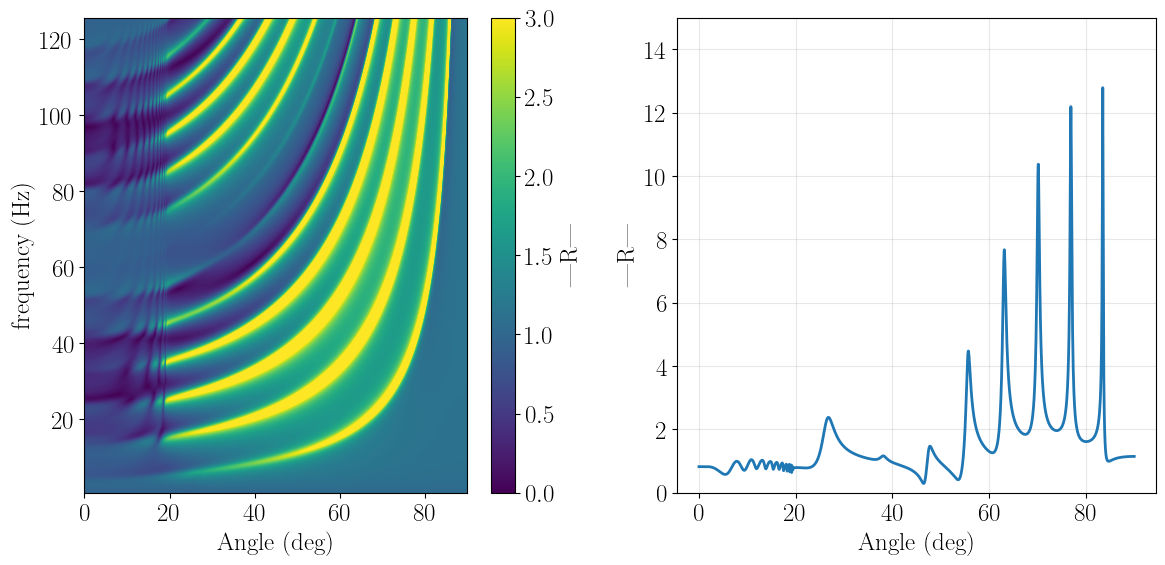

In [ ]:
from src.reflectivity_kx_omega import reflectivity
thetas = np.linspace(0., np.pi/2., 2048)
omegas = 2*np.pi * np.linspace(0.1, 20, 2048) 
Rmap = reflectivity(layers, omegas+ 1.0*1j, thetas, 76., 76., mode="k0",  use_numba=True, fs=True) 

fixed_omega = 80.
omega_idx = np.argmin(np.abs(omegas - fixed_omega))
R_at_omega = np.abs(Rmap[omega_idx, :])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(np.abs(Rmap), origin='lower',
            extent=[180.*thetas[0]/np.pi, 180.*thetas[-1]/np.pi, omegas[0], omegas[-1]],
            aspect='auto',
            vmin=0, vmax=3.0)
plt.xlabel('Angle (deg)')
plt.ylabel('frequency (Hz)')
plt.colorbar(label='|R|')

plt.subplot(1,2,2)

plt.plot(180.*thetas/np.pi, R_at_omega, linewidth=2)

plt.xlabel('Angle (deg)')
plt.ylabel('|R|')
plt.grid(True, alpha=0.3)
plt.ylim([0, 15.0])
plt.tight_layout()
plt.show()

In [102]:
# there is currently no loop over the number of receivers
d_cal = forward(layers, acq, param, nq_prop=1024, nq_evan=64, free_surface=True)

first freq 0.0
max epsilon = 1.956011502714073
reflectivity prop elapsed: 1.51 s
reflectivity evan elapsed: 0.02 s
quad prop elapsed: 0.31 s
quad evanes elapsed: 0.00 s
quad prop elapsed: 0.30 s
quad evanes elapsed: 0.00 s
kx quadrature elapsed: 70.72 s


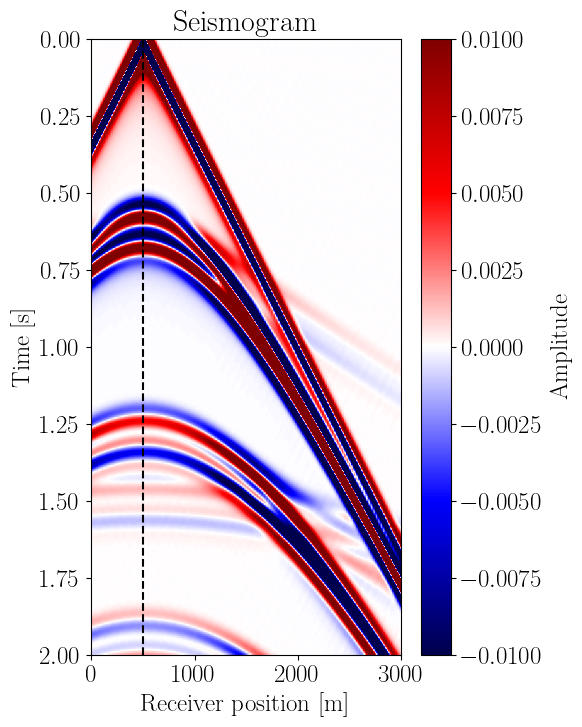

In [103]:
d_cal_seis = d_cal[1, :, :]

Ncolors = 256
cmap = plt.cm.seismic
colors = cmap(np.linspace(0, 1, Ncolors))
cmap_discrete = ListedColormap(colors)
plt.figure(figsize=(5,8))
plt.imshow(d_cal_seis.T, aspect='auto', origin='upper', 
           extent=[np.min(acq.xr), np.max(acq.xr), param.time[-1], param.time[0]],
           cmap=cmap_discrete, vmin=-0.01, vmax=0.01)
plt.colorbar(label='Amplitude')
plt.axvline(x=500, linewidth=1.5, linestyle='--', color='black')
plt.xlabel('Receiver position [m]')
plt.ylabel('Time [s]')
plt.title('Seismogram ')
plt.show()

Delay 0.2
Reflection coeff: 0.5
time refl 0.516 seconds
time refl 2 fs 0.5666666666666667 seconds
time refl 1.1826666666666665 seconds
r_dist 1400.0 r_travel 1636.79687194227


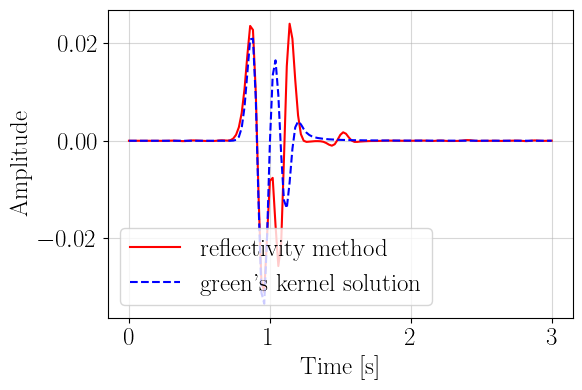

In [ ]:
# validation with green's function in frequency domain
rn = 6
sn = 0
freqs = np.fft.rfftfreq(param.nfft, param.dt)
omegas = 2.0 * np.pi * freqs  + 1j * 1e-12
s_t, delay = ricker_wavelet(param.time, param.freq)
print("Delay", delay)
s_w = np.conj(np.fft.rfft(np.conj(s_t), n=param.nfft)) 

Reflection = (layers[1][1] - layers[0][1])/(layers[0][1] + layers[1][1])
print("Reflection coeff:", Reflection)
vp = layers[0][1]
h = layers[0][0]
r_dist = np.sqrt( (acq.xs[sn] - acq.xr[rn])**2 + (acq.zs[sn] - acq.zr[rn])**2 )
r_travel = 2.*np.sqrt( (h-acq.zs[sn])**2 + (0.5*(acq.xs[sn] - acq.xr[rn]))**2 )
time_reflection = (2*h - 76.) / (vp) - 0.1
print("time refl", time_reflection, "seconds")

time_reflection2 = (2*h - 0.) / (vp) - 0.1
print("time refl 2 fs", time_reflection2, "seconds")

time_reflection3 = (4*h - 76.) / (vp) - 0.1
print("time refl", time_reflection3, "seconds")

print("r_dist", r_dist, "r_travel", r_travel)
T_ref = s_w*(green2d(omegas, vp, r_dist) + Reflection*green2d(omegas, vp, r_travel)) * np.exp(-1j * delay * omegas)
# T_ref *= 1j*omegas # ricker source time-derivative !
S_ref = np.conj(np.fft.irfft(np.conj(T_ref), n=param.nfft))
S_ref = S_ref[:param.nt]

plt.figure(figsize=(6,4))
plt.plot(param.time, d_cal[sn, rn, :], 'r-', label='reflectivity method')
plt.plot(param.time, S_ref, 'b--', label='green\'s kernel solution')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
#plt.ylim(-0.05, 0.05)

In [ ]:
from src.misfit import l2_misfit
misfit = l2_misfit(d_cal[sn, rn, :], S_ref, layers=layers, acqui=acq, param=param)
print("L2 misfit between reflectivity and green's function solution:", misfit)

L2 misfit between reflectivity and green's function solution: 0.004425438896249888
